## Optimization Project

In [133]:
from IPython.display import Image
from gurobipy import *
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from math import sqrt
import yfinance as yf
import matplotlib.ticker as mtick


#### REPORT: Data Collection

In [134]:
tickers = ["NVDA", "GOOG", "AVGO", "AAPL", "META"]
start_date = "2025-01-02"
end_date = "2025-12-31"

prices = yf.download(
    tickers,
    start=start_date,
    end=end_date
)["Close"]

data_stock = prices.pct_change(fill_method=None).dropna()

data_stock.head()

[*********************100%***********************]  5 of 5 completed


Ticker,AAPL,AVGO,GOOG,META,NVDA
Date,,,,,
2025-01-03,-0.002009,0.002457,0.013114,0.008995,0.044538
2025-01-06,0.006739,0.016599,0.025009,0.042290,0.034332
2025-01-07,-0.011388,-0.032867,-0.006314,-0.019533,-0.062170
2025-01-08,0.002023,0.002930,-0.006711,-0.011604,-0.000214
2025-01-10,-0.024104,-0.021805,-0.011362,0.008416,-0.029976


#### Optimizing the Portfolio

In [135]:
stocks = data_stock.columns
num_stocks=len(stocks)

### Get all of the expected returns
stock_return = data_stock.mean()

### Get covariance matrix
cov_mat=data_stock.cov()

# Create an empty model
m = Model('portfolio')

# Add a variable for each stock
vars = pd.Series(m.addVars(stocks, lb=0), index=stocks)

# Set objective
portfolio_risk = cov_mat.dot(vars).dot(vars)
m.setObjective(portfolio_risk, GRB.MINIMIZE)

# Constraints
m.addConstr(vars.sum() == 1, 'budget') # proportions sum to 1 constraint
m.addConstr(stock_return @ vars >= 0.0018, 'return') # 0.18% daily return constraint

m.optimize()

print('Minimum Risk Portfolio:\n')
if m.status == GRB.OPTIMAL:
    for stock, var in vars.items():
        if var.X > 0:
            print(f'{stock} : {var.X}')
else:
    print("Model not solved optimally.")


Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (mac64[arm] - Darwin 25.3.0 25D125)

CPU model: Apple M4
Thread count: 10 physical cores, 10 logical processors, using up to 10 threads

Optimize a model with 2 rows, 5 columns and 10 nonzeros (Min)
Model fingerprint: 0x4ffc453a
Model has 0 linear objective coefficients
Model has 15 quadratic objective terms
Coefficient statistics:
  Matrix range     [7e-04, 1e+00]
  Objective range  [0e+00, 0e+00]
  QObjective range [8e-04, 3e-03]
  Bounds range     [0e+00, 0e+00]
  RHS range        [2e-03, 1e+00]

Presolve time: 0.00s
Presolved: 2 rows, 5 columns, 10 nonzeros
Presolved model has 15 quadratic objective terms
Ordering time: 0.00s

Barrier statistics:
 Free vars  : 4
 AA' NZ     : 1.500e+01
 Factor NZ  : 2.100e+01
 Factor Ops : 9.100e+01 (less than 1 second per iteration)
 Threads    : 1

                  Objective                Residual
Iter       Primal          Dual         Primal    Dual     Compl     Time
   0   7.58650018e+03 -7.5

#### REPORT: Creating Efficient Frontier

Discarded solution information


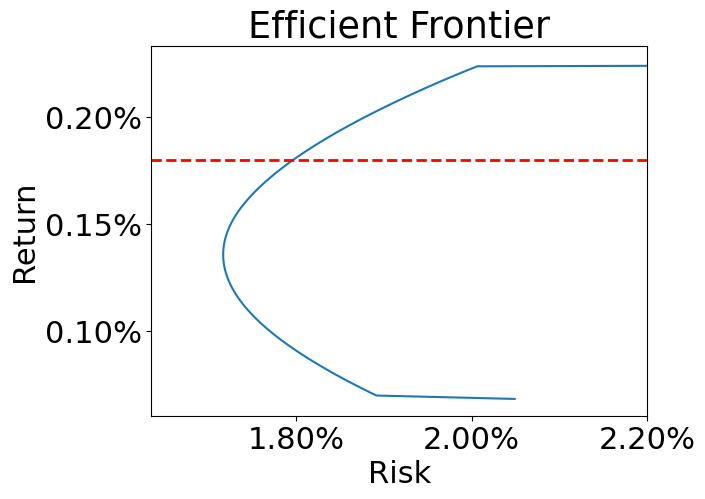

In [136]:
# Calculate basic summary statistics for individual stocks
stock_volatility = data_stock.std()
stock_return = data_stock.mean()
cov_mat=data_stock.cov()

min_ret = stock_return.min() # minimum return 
max_ret = stock_return.max() # maximum return
returns = np.linspace(min_ret, max_ret, 100)
ret_list = [] # list of returns
risks = [] # list of correlating risks
props = [] # list of proportions

# Loop through all returns and optimize risk then pulling off objective function, constraints, and decision variables
for ret in returns:
  m.reset(0)
  m = Model("Portfolio_Optimization")
  m.setParam('OutputFlag', 0)
  vars=pd.Series(m.addVars(stocks,lb=0), index=stocks)
  portfolio_risk = cov_mat.dot(vars).dot(vars)
  m.setObjective(portfolio_risk, GRB.MINIMIZE) # minimize risk
  m.addConstr(vars.sum() == 1, name = 'budget' ) # proportions sum to 1 constraint
  m.addConstr(stock_return.dot(vars) == ret , name = 'return_sim' )
  m.update()
  m.optimize()
  risks.append(np.sqrt(m.objval ) )
  ret_list.append(stock_return.dot(m.x) )
  props.append(m.x)
  
# Plotting the efficient frontier
plt.rcParams.update({'font.size': 22})
plt.plot(risks, returns)
plt.xlabel('Risk')
plt.ylabel('Return')
plt.title('Efficient Frontier')
plt.gca().xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=2)) # convert x axis to decimal
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=2)) # convert y axis to decimal
plt.axhline(y=0.0018, color='red', linestyle='--', linewidth=2, label='0.18% Target') # horizontal line at 0.18% return
plt.xlim(right=0.022)

plt.show()

Note: It looks like return flattens after about 0.225% because this is the maximum return of any of the stocks, which makes it the maximum feasible return

#### REPORT: Portfolio Options: High-risk and low-risk

In [137]:
# A function to get the proportion of each stock in a portfolio based on a defined return
def get_portfolio_for_target_return(target_return):
    """Returns portfolio weights for a given target return."""
    m = Model("Target_Return_Portfolio")
    m.setParam('OutputFlag', 0)
    
    # Decision variables
    vars = pd.Series(m.addVars(stocks, lb=0), index=stocks)
    
    # Objective: minimize portfolio variance
    portfolio_risk = vars @ cov_mat @ vars
    m.setObjective(portfolio_risk, GRB.MINIMIZE)
    
    # Constraints
    m.addConstr(vars.sum() == 1, "budget") # sum of weights = 1
    m.addConstr(stock_return @ vars == target_return, "target_return") # exact return
    
    m.optimize()
    
    if m.status == GRB.OPTIMAL:
        weights = {stock: vars[stock].X for stock in stocks if vars[stock].X > 0.001}  # filter tiny weights
        risk = np.sqrt(m.objVal)
        return weights, risk
    else:
        print("No optimal solution for target return:", target_return)
        return None, None

# Low-risk portfolio
low_risk_weights, low_risk = get_portfolio_for_target_return(0.0018) # 0.0018 is the minimum return required in the assignment

# Medium-risk portfolio
medium_risk_weights, medium_risk = get_portfolio_for_target_return(0.002025) # The average of the high and low risk values
# High-risk portfolio
high_risk_weights, high_risk = get_portfolio_for_target_return(0.00225) # 0.00225 is the rounded maximum return of any of the 5 stock

##### REPORT: Display the Portfolios

In [142]:
print("Low-Risk Portfolio (0.18% return per day, risk {:.2f}%):".format(low_risk*100)) # weird coincidence that the return is 0.18% and risk is 1.8% but it is correct
for stock, weight in low_risk_weights.items():
    print(f"  {stock}: {weight*100:.2f}%")

print("Medium-Risk Portfolio (0.2025% return per day, risk {:.2f}%):".format(medium_risk*100)) 
for stock, weight in medium_risk_weights.items():
    print(f"  {stock}: {weight*100:.2f}%")

print("\nHigh-Risk Portfolio (0.225% return per day, risk {:.2f}%):".format(high_risk*100))
for stock, weight in high_risk_weights.items():
    print(f"  {stock}: {weight*100:.2f}%")

Low-Risk Portfolio (0.18% return per day, risk 1.80%):
  AAPL: 19.66%
  AVGO: 2.47%
  GOOG: 69.10%
  META: 8.77%
Medium-Risk Portfolio (0.2025% return per day, risk 1.89%):
  AAPL: 10.94%
  AVGO: 5.34%
  GOOG: 80.80%
  META: 2.92%

High-Risk Portfolio (0.225% return per day, risk 2.63%):
  AVGO: 66.17%
  GOOG: 33.83%


Note: NVDA isn't present in any of these. It's likely because it has high volatility and doesn't contribute to an average daily return of 0.18% in any combination

#### Investigating why NVDA is absent

In [141]:
print(stock_volatility)
print(stock_return)

Ticker
AAPL    0.020489
AVGO    0.033552
GOOG    0.020177
META    0.023995
NVDA    0.031328
dtype: float64
Ticker
AAPL    0.000681
AVGO    0.002256
GOOG    0.002239
META    0.000723
NVDA    0.001721
dtype: float64


It looks like NVDA has average return but the 2nd highest volatility, so the algorithm must have just weeded it out